In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [7]:
# Cargar dataset final
df = pd.read_csv("../Data/Raw/Output/04_data_final.csv", parse_dates=["timestamp", "release_date"])

print(df.shape)

(70000, 29)


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 29 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   userId             70000 non-null  int64         
 1   movieId            70000 non-null  int64         
 2   rating             70000 non-null  float64       
 3   timestamp          70000 non-null  datetime64[us]
 4   genres_x           70000 non-null  str           
 5   imdbId             70000 non-null  int64         
 6   tmdbId             70000 non-null  int64         
 7   budget             70000 non-null  float64       
 8   homepage           70000 non-null  str           
 9   id                 70000 non-null  int64         
 10  keywords           70000 non-null  str           
 11  original_language  70000 non-null  str           
 12  original_title     70000 non-null  str           
 13  popularity         70000 non-null  float64       
 14  release_date     

In [9]:
#cambiamos la columna "tmsbId" de tipo float a tipo int
df["tmdbId"] = df["tmdbId"].astype(int)

In [12]:
id_columns = ["userId","imdbId", "tmdbId", "movieId", "id", "movie_id"]
for col in id_columns:
    df[col] = df[col].astype(str)

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 29 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   userId             70000 non-null  str           
 1   movieId            70000 non-null  str           
 2   rating             70000 non-null  float64       
 3   timestamp          70000 non-null  datetime64[us]
 4   genres_x           70000 non-null  str           
 5   imdbId             70000 non-null  str           
 6   tmdbId             70000 non-null  str           
 7   budget             70000 non-null  float64       
 8   homepage           70000 non-null  str           
 9   id                 70000 non-null  str           
 10  keywords           70000 non-null  str           
 11  original_language  70000 non-null  str           
 12  original_title     70000 non-null  str           
 13  popularity         70000 non-null  float64       
 14  release_date     

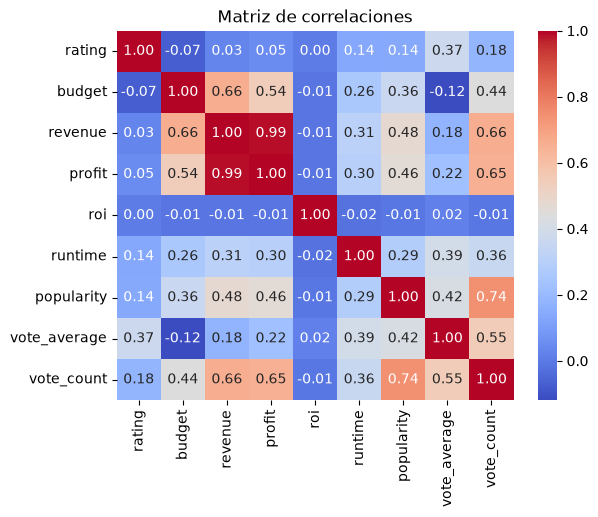

In [14]:
columnas = [
    "rating",
    "budget",
    "revenue",
    "profit",
    "roi",
    "runtime",
    "popularity",
    "vote_average",
    "vote_count"
]

correlaciones = df[columnas].corr()

sns.heatmap(
    correlaciones,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matriz de correlaciones")
plt.show()

La matriz de correlaciones muestra una relación positiva fuerte entre popularidad y número de votos (r=0,74), así como entre presupuesto e ingresos (r=0,66). También se observa una relación positiva moderada entre popularidad e ingresos (r=0,48). Por otro lado, el ROI presenta correlaciones próximas a cero con el resto de variables, lo que sugiere que su comportamiento no está explicado por una relación lineal simple con las variables analizadas.
Dado que profit procede de la diferencia entre profit y revenue es entendible la relación positiva fuerte (r=0,99) a mayor ingreso mayor beneficio se obtendrá.

Presupuesto e ingresos - ¿las peliculas con mayor presupuesto tienden a generar mayores ingresos?

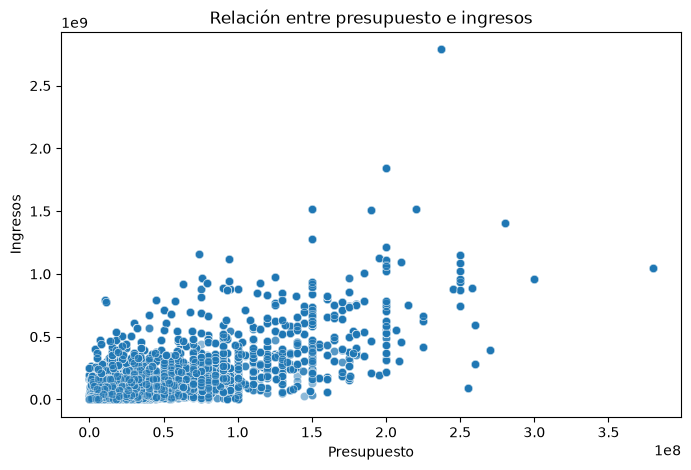

In [17]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="budget",
    y="revenue",
    alpha=0.5
)

plt.title("Relación entre presupuesto e ingresos")
plt.xlabel("Presupuesto")
plt.ylabel("Ingresos")
plt.show()

Se observa una correlación entre el presupuesto y los ingresos, sugiere que las peliculas con mayor presupuesto tienden a generar mayores ingresos, aunque la dispersión indica a su vez que una inversión elevada no garantiza necesariamente un mayor éxito económico.

Analizamos la relación popularity y vote count - ¿las películas más populares acumulan más votos?

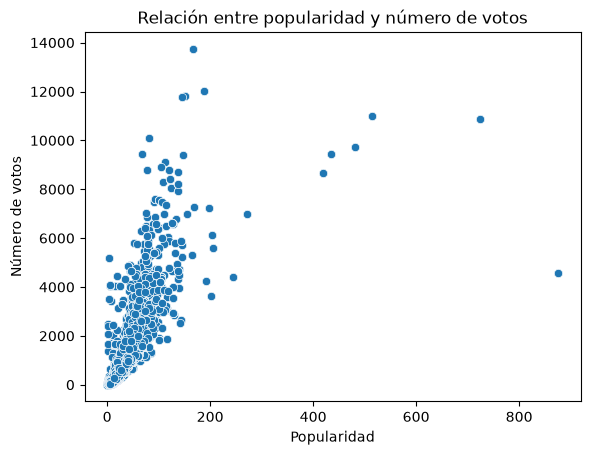

In [19]:
sns.scatterplot(
    data=df,
    x="popularity",
    y="vote_count"
)

plt.title("Relación entre popularidad y número de votos")
plt.xlabel("Popularidad")
plt.ylabel("Número de votos")
plt.show()

se observa una relación positiva fuerte, lo que indica que las peliculas mas populares suelen acumular un mayor volumen de valoraciones por parte del publico

Analizamos la relación entre popularidad e ingresos - ¿las películas más populares generan mayores ingresos?

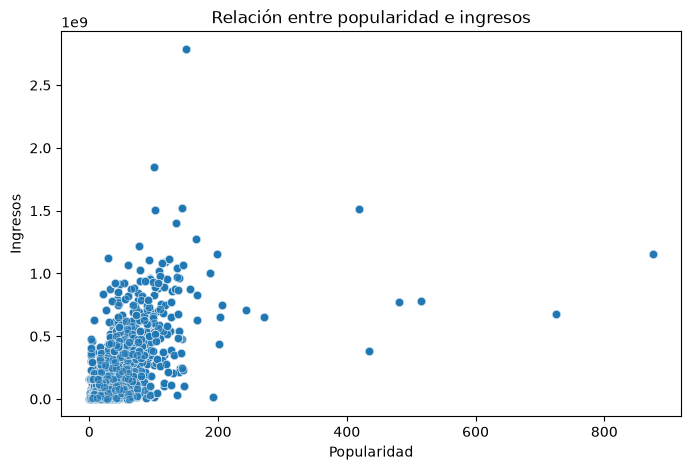

In [20]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="popularity",
    y="revenue",
    alpha=0.5
)

plt.title("Relación entre popularidad e ingresos")
plt.xlabel("Popularidad")
plt.ylabel("Ingresos")
plt.show()

Se observa relación positiva moderada. las peliculas mas populares suelen generar mayores ingresos, aunque hay excepciones marcadas por los outliers, películas muy populares con ingresos no demesiado altos pero en general sí que hay una relación fuerte, cuanto más popular es la película mayores son los ingresos

Ahora analizamos la relación entre dos valores relacionadas con la valoración. ¿se valora igual una misma pelicula en fuentes distintas?

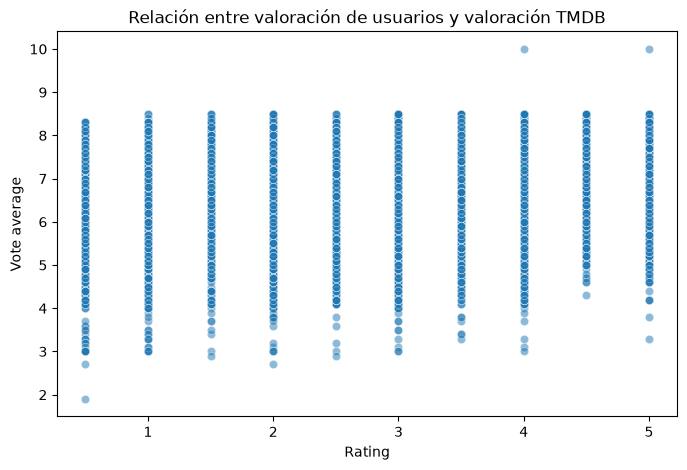

In [21]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="rating",
    y="vote_average",
    alpha=0.5
)

plt.title("Relación entre valoración de usuarios y valoración TMDB")
plt.xlabel("Rating")
plt.ylabel("Vote average")
plt.show()

Ambas plataformas muestran una tendencia similar en las valoración de las películas. Sin embargo, se observa una mayor dispersión en las puntuaciones de TMSB, lo que puede deberse a diferencias en las metodologías de valoración utlizadas por ambas plataformas

Analizamos el ROI

In [37]:
porcentaje_rentables = (df["profit"] > 0).mean() * 100

print(f"Películas rentables: {porcentaje_rentables:.2f}%")
print(f"Películas no rentables: {100 - porcentaje_rentables:.2f}%")


Películas rentables: 93.47%
Películas no rentables: 6.53%


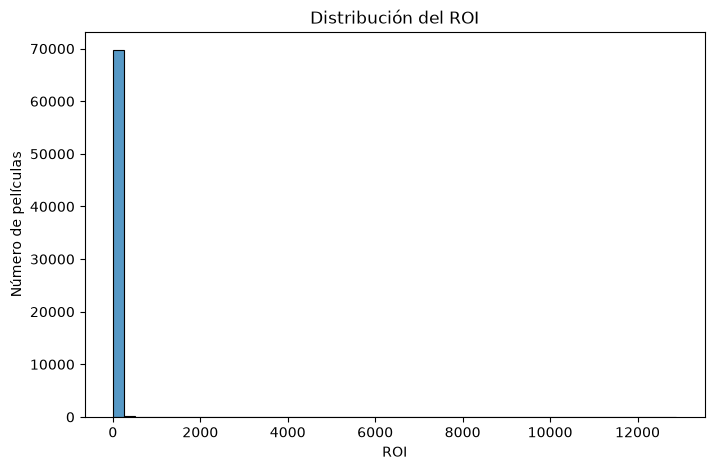

In [38]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="roi",
    bins=50
)

plt.title("Distribución del ROI")
plt.xlabel("ROI")
plt.ylabel("Número de películas")
plt.show()

In [39]:
df["budget_group"] = pd.qcut(
    df["budget"],
    q=4,
    labels=[
        "Bajo",
        "Medio-bajo",
        "Medio-alto",
        "Alto"
    ]
)

In [40]:
roi_presupuesto = df.groupby("budget_group", observed=True)["roi"].mean()

print(roi_presupuesto)

budget_group
Bajo          46.624384
Medio-bajo     6.090539
Medio-alto     3.547727
Alto           3.190027
Name: roi, dtype: float64


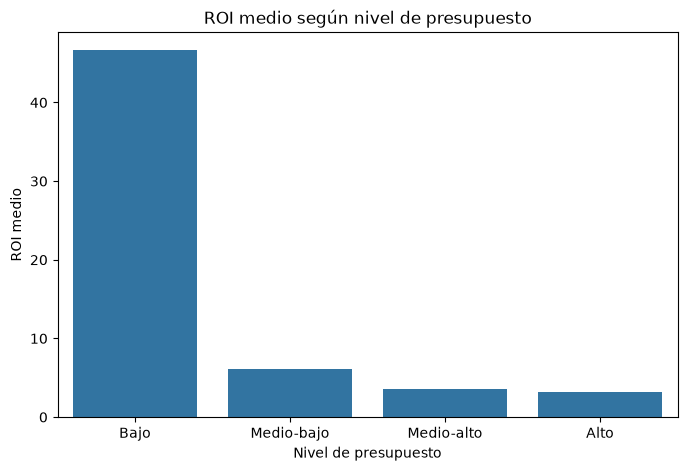

In [41]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=roi_presupuesto.index,
    y=roi_presupuesto.values
)

plt.title("ROI medio según nivel de presupuesto")
plt.xlabel("Nivel de presupuesto")
plt.ylabel("ROI medio")
plt.show()

In [28]:
df["roi"].describe()

count    7.000000e+04
mean     1.714795e+03
std      1.201969e+05
min     -9.999995e-01
25%      1.614485e+00
50%      3.350384e+00
75%      7.300000e+00
max      8.499999e+06
Name: roi, dtype: float64

In [42]:
df.nlargest(10, "roi")[["original_title", "budget", "revenue", "profit", "roi"]]

,original_title,budget,revenue,profit,roi
2010,Paranormal Activity,15000.0,193355800.0,193340800.0,12889.386667
17668,Paranormal Activity,15000.0,193355800.0,193340800.0,12889.386667
23184,Paranormal Activity,15000.0,193355800.0,193340800.0,12889.386667
26155,Paranormal Activity,15000.0,193355800.0,193340800.0,12889.386667
31992,Paranormal Activity,15000.0,193355800.0,193340800.0,12889.386667
50270,Paranormal Activity,15000.0,193355800.0,193340800.0,12889.386667
53450,Paranormal Activity,15000.0,193355800.0,193340800.0,12889.386667
64439,Paranormal Activity,15000.0,193355800.0,193340800.0,12889.386667
66043,Paranormal Activity,15000.0,193355800.0,193340800.0,12889.386667
1500,The Blair Witch Project,60000.0,248000000.0,247940000.0,4132.333333


Se observa que hay valores de budget que no son reales por lo que el roi no está dando un resultado real

In [31]:
df.loc[df["budget"] < 10000, "budget"] = np.nan

In [114]:
df["budget"] = (df["budget"].fillna(df["budget"].median()))

In [89]:
df["profit"] =(df["revenue"]-df["budget"])

In [90]:
df["roi"] = (df["profit"]/df["budget"])

In [91]:
df["roi"].describe()

count    70000.000000
mean        15.286156
std        206.691578
min         -1.000000
25%          1.525722
50%          3.443111
75%          7.591719
max      12889.386667
Name: roi, dtype: float64

La distribución del ROI presenta una fuerte asimetría positiva a la derecha. Aunque la media alcanza valores elevados (ROI medio = 15,3) la mediana se sitúa en 3,44 indicando que unos pocos éxitos extraordinarios incrementan significativamente el promedio. La mayoria de los registros presentan retornos mucho mas moderados. Por este motivo, la mediana resulta una medida más representativa para describir el comportamiento típico de la rentabilidad de las películas.

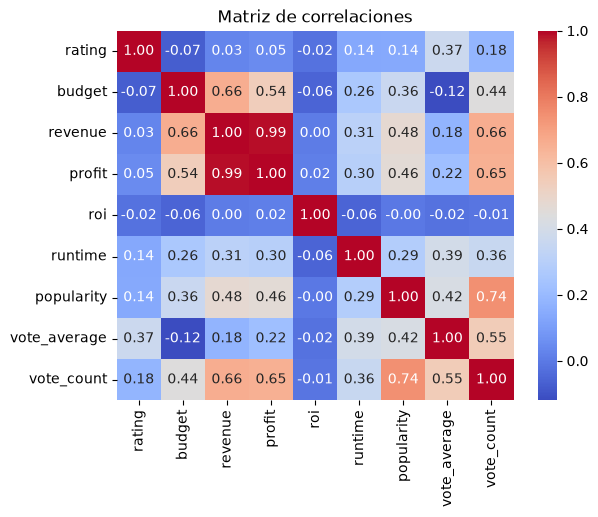

In [92]:
columnas = [
    "rating",
    "budget",
    "revenue",
    "profit",
    "roi",
    "runtime",
    "popularity",
    "vote_average",
    "vote_count"
]

correlaciones = df[columnas].corr()

sns.heatmap(
    correlaciones,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matriz de correlaciones")
plt.show()

In [93]:
roi_presupuesto = (df.groupby("budget_group")["roi"].median())

print(roi_presupuesto)

budget_group
Bajo          7.958644
Medio-bajo    3.867845
Medio-alto    2.496923
Alto          2.706469
Name: roi, dtype: float64


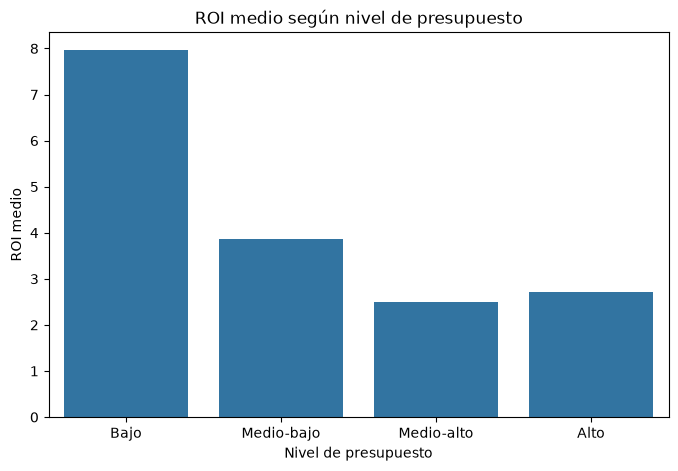

In [94]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=roi_presupuesto.index,
    y=roi_presupuesto.values
)

plt.title("ROI medio según nivel de presupuesto")
plt.xlabel("Nivel de presupuesto")
plt.ylabel("ROI medio")
plt.show()

Las películas de menor presupuesto presentan, en general, un ROI mediano superior al de las producciones con presupuestos más elevados. Esto sugiere que las producciones pequeñas pueden obtener retornos proporcionales mas altos respecto a la inversión realizada. Por el contrario, las películas con presupuestos elevados suelen generar mayores ingresos absolutos, pero tambien requieren inversiones significativamente superiores, reduciendo su rentabilidad relativa.

El ROI presenta una distribución fuertemente asimétrica positiva. La mayoria de las películas muestran valores relativamente moderados de rentabilidad, mientras que un reducido grupo de películas alcanza retornos excepcionalmente elevados. Tras revisar los presupuestos anomalamente bajos presentes en la fuente original y tratarlos como valores faltantes, los indicadores de rentabilidad resultan más consistentes. Sin embargo, la existencia de algunos éxitos extraordinarios sigue provocando diferencias significativas entre la media y la mediana del ROI. Por este motivo, la mediana se considera una medida más representativa del comportamiento habitual de la rentabilidad que la media.

Analizamos GENERO *main_genre*

In [95]:
rating_genero = df.groupby("main_genre")["rating"].mean().sort_values(ascending=False)
rating_genero.head(10)

main_genre
Mystery               3.987558
Crime                 3.923898
Thriller              3.776803
Musical               3.773973
War                   3.750000
Drama                 3.722677
(no genres listed)    3.700000
Documentary           3.667797
Adventure             3.657556
Western               3.601010
Name: rating, dtype: float64

<Axes: xlabel='main_genre'>

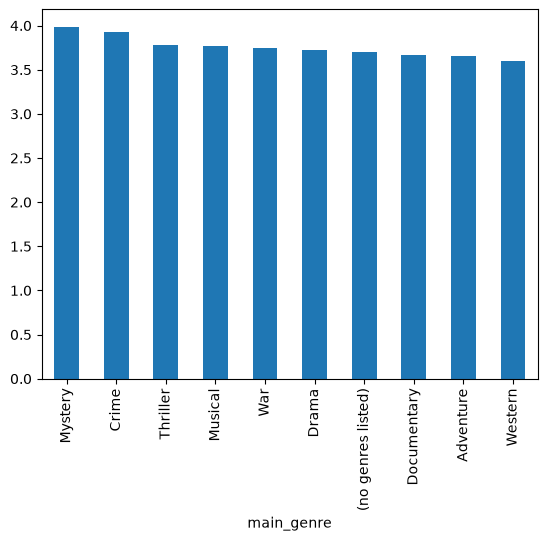

In [96]:
rating_genero.head(10).plot(kind="bar")

El genero que mayor rating tiene (mejor valorado) es "mistery", seguido de "crime" y "thriller", el resto de géneros tiene una valoración muy similar por encima del 3.5

In [97]:
#revenue por género
revenue_genero = df.groupby("main_genre")["revenue"].mean().sort_values(ascending=False)
revenue_genero.head(10)

main_genre
Adventure    4.049994e+08
Sci-Fi       3.799301e+08
Action       3.380229e+08
Animation    2.806508e+08
Children     2.618438e+08
Musical      2.618399e+08
Thriller     2.325628e+08
Mystery      1.770606e+08
Drama        1.661177e+08
War          1.606389e+08
Name: revenue, dtype: float64

Los géneros de películas que más ingresos obtienen son "adventure", "Sci-Fi" y "action"

In [98]:
#Popularidad media por género
popularidad_genero = df.groupby("main_genre")["popularity"].mean().sort_values(ascending=False)
popularidad_genero.head(10)

main_genre
Sci-Fi       336.770641
Adventure     65.152550
Action        61.091735
Mystery       60.541864
Crime         56.053678
Animation     48.588754
Fantasy       39.981790
Drama         39.395097
Thriller      38.298248
Horror        36.636624
Name: popularity, dtype: float64

Los géneros que mayor popularidad tienen son "Sci-Fi", "Adventure" y "Action". Lo que está en línea con los géneros que más ingresos obtienen

Analizamos IDIOMA *original_language*

In [99]:
df["original_language"].value_counts().head(10)

original_language
en    68154
ja      304
fr      299
es      254
de      249
zh      173
it      135
cn      104
ko       94
pt       93
Name: count, dtype: int64

In [100]:
rating_language = df.groupby("original_language")["rating"].mean().sort_values(ascending=False)
rating_language.head(10)

original_language
ps    5.000000
pl    4.500000
he    4.400000
pt    4.225806
sv    4.111111
ja    4.032895
it    4.022222
de    4.016064
xx    4.000000
ko    3.984043
Name: rating, dtype: float64

Las películas mejor valoradas son aquellas producidas en idiomas "ps" - pashto oficial de Afganistán y Pakistán, "pl" - polaco y "he" hebreo

In [101]:
df.groupby("original_language")["vote_average"].mean().sort_values(ascending=False)

original_language
ja    8.057566
pt    8.036559
it    7.897037
he    7.800000
fa    7.753846
de    7.548193
sv    7.533333
ko    7.524468
nl    7.450000
id    7.371429
fr    7.354181
ro    7.300000
da    7.295122
es    7.225591
zh    7.152601
xx    7.100000
pl    7.100000
hi    6.963636
en    6.950606
ru    6.922222
el    6.900000
af    6.900000
th    6.800000
ar    6.800000
cn    6.719231
nb    6.700000
ps    6.300000
no    6.100000
Name: vote_average, dtype: float64

Las películas en japonés, portugés e italiano tienen una media de votos más alta que la del resto de idiomas

In [102]:
df.groupby("original_language")["revenue"].mean().sort_values(ascending=False)

original_language
en    2.544490e+08
zh    1.878467e+08
ps    1.606389e+08
ar    1.606389e+08
sv    1.606389e+08
ja    1.538015e+08
fr    1.222236e+08
hi    1.050861e+08
ru    9.545068e+07
nl    9.341598e+07
da    7.850207e+07
fa    7.462564e+07
cn    6.660240e+07
es    6.441423e+07
xx    5.526056e+07
de    5.129179e+07
ko    4.323679e+07
pt    3.214221e+07
th    2.716558e+07
it    1.456962e+07
he    1.112585e+07
pl    1.070000e+07
af    9.879971e+06
nb    4.159678e+06
id    2.797826e+06
no    1.984662e+06
ro    1.185783e+06
el    1.101970e+05
Name: revenue, dtype: float64

A pesar de que las películas mejor valoradas en cuanto a idioma son las que hemos visto anteriormente, son las de idioma original en inglés las que más ingresos recaudan, seguidas de Zh - idioma hablado en China y Ps - pashto, que sí que aparece en las de mayor rating.

Analizamos DIRECTOR *director*

In [103]:
top_director = (df.groupby("director")["rating"].mean().sort_values(ascending=False))
top_director.head(10)


director
Alison Maclean          5.0
Kay Pollak              5.0
James D. Stern          5.0
Hilary Brougher         5.0
Michael Patrick King    5.0
Jack Smight             5.0
Lisanne Pajot           5.0
Marcus Dunstan          5.0
Gary Sinyor             5.0
Siddiq Barmak           5.0
Name: rating, dtype: float64

Los 10 directores mejores valorados tienen una puntuación de 5

Analizamos los años de producción de las películas, su evolución *release_year*


In [104]:
rating_year = df.groupby("release_year")["rating"].mean().sort_values(ascending=False)
rating_year.head(10)

release_year
1947    5.000000
1972    4.274194
1955    4.250000
1959    4.226190
1927    4.214286
1946    4.176923
1957    4.092000
1942    4.082143
1961    4.072917
1934    4.071429
Name: rating, dtype: float64

In [105]:
revenue_year = df.groupby("release_year")["revenue"].mean().sort_values(ascending=False)
revenue_year.head(10)

release_year
1977    5.408660e+08
2016    5.194138e+08
2012    4.594994e+08
2015    4.305108e+08
2009    4.246481e+08
2014    3.784899e+08
2003    3.622353e+08
2010    3.468388e+08
2013    3.403248e+08
2008    3.291777e+08
Name: revenue, dtype: float64

Vemos que en general las películas mejores valoradas son las del siglo XX, principalmente entre la decada de los 50 y 70, mientras que las películas que mayores ingresos han obtenido son aquellas pertenecientes al siglo XXI entre 2003 y 2016.

Analizamos los PAISES "main_country"

In [106]:
df.groupby("main_country")["rating"].mean().sort_values(ascending=False)

main_country
Afghanistan                 5.000000
Malta                       4.500000
Israel                      4.400000
Hungary                     4.333333
Sweden                      4.250000
Bosnia and Herzegovina      4.166667
Indonesia                   4.111111
South Korea                 3.984043
Finland                     3.916667
Austria                     3.906780
India                       3.891304
New Zealand                 3.887810
Iceland                     3.807692
South Africa                3.789474
Brazil                      3.774194
Italy                       3.755924
Bahamas                     3.750000
Libyan Arab Jamahiriya      3.750000
Denmark                     3.750000
Spain                       3.727891
Argentina                   3.714286
Iran                        3.692308
United Kingdom              3.689016
Japan                       3.670507
Ecuador                     3.666667
Malaysia                    3.666667
China                    

teniendo en cuenta la muestra, las peliculas mejor valoradas son las realizadas Afghanistan, Malta e Israel

CONSIDERACIÓN : Los resultados obtenidos para variables categóricas como "país", "idioma", "director" deben interpretarse con cautela. Algunas categorías cuentan con un nukero reducido de peliculas dentro del conjunto de datos, por lo que una o varias observaciones excepcionalmente bien valoradas o rentables pueden influir significativamente en la media del grupo. En consecuencia, los resultados observados no deben interpretarse necesariamente como una evidencia de que todas las peliculas de un determinado pais, idioma o director presentan un mejor rendimiento/ valoración, sino como una descripción de la muestra analizada.

Veamos que ocurre cuando hacemos un df filtrado cuando el main_country aparece mínimo 20 veces

In [107]:
conteo_paises = df["main_country"].value_counts()
paises_validos =conteo_paises[conteo_paises >= 20].index
df_paises =df[ df["main_country"].isin(paises_validos)]

In [108]:
df_paises = df[df["main_country"].isin(paises_validos)]

In [109]:
rating_paises =(df_paises.groupby("main_country")["rating"].mean().sort_values(ascending=False))
rating_paises.head(10)

main_country
South Korea    3.984043
Austria        3.906780
India          3.891304
New Zealand    3.887810
Iceland        3.807692
Brazil         3.774194
Italy          3.755924
Denmark        3.750000
Spain          3.727891
Argentina      3.714286
Name: rating, dtype: float64

Como podemos ver, el resultado ha cambiado por completo, el top 3 es ahora South Korea, Austria e India.

Hacemos la comprobación para directores con más de 3 películas para comprobar si hay diferencia

In [110]:
conteo_directores = df["director"].value_counts()
directores_validos = conteo_directores[conteo_directores>=3].index
df_directores = df[df["director"].isin(directores_validos)]

In [111]:
top_directores = (df_directores.groupby("director")["rating"].mean().sort_values(ascending=False).head(10))
top_directores 

director
Kang Je-gyu       4.833333
Ari Folman        4.400000
Miranda July      4.375000
Mark Illsley      4.375000
Andrew Currie     4.333333
Frank Darabont    4.303427
Stacy Peralta     4.300000
Robert Rossen     4.291667
Goran Dukic       4.277778
John Sayles       4.267857
Name: rating, dtype: float64

In [112]:
top_director.head(10)

director
Alison Maclean          5.0
Kay Pollak              5.0
James D. Stern          5.0
Hilary Brougher         5.0
Michael Patrick King    5.0
Jack Smight             5.0
Lisanne Pajot           5.0
Marcus Dunstan          5.0
Gary Sinyor             5.0
Siddiq Barmak           5.0
Name: rating, dtype: float64

Se puede observar que el top 10 ha cambiado tanto de la puntuación obtenida, anteriormente el top 10 tenian todos puntuacion de 5 mientras que ahora el que mayor puntuación tiene es de 4,83. y los nombres de los directores cambian todos.

In [113]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   userId             70000 non-null  str           
 1   movieId            70000 non-null  str           
 2   rating             70000 non-null  float64       
 3   timestamp          70000 non-null  datetime64[us]
 4   genres_x           70000 non-null  str           
 5   imdbId             70000 non-null  str           
 6   tmdbId             70000 non-null  str           
 7   budget             70000 non-null  float64       
 8   homepage           70000 non-null  str           
 9   id                 70000 non-null  str           
 10  keywords           70000 non-null  str           
 11  original_language  70000 non-null  str           
 12  original_title     70000 non-null  str           
 13  popularity         70000 non-null  float64       
 14  release_date     